# 🏎️ F1 Lap Time Prediction — Multi-Year Model (2022–2025)
## Spanish Grand Prix — Circuit de Barcelona-Catalunya

**Data:** 2022, 2023, 2024, 2025 Spanish GP laps  
**Drivers:** Only those with a **stable team** across all 4 years

| Driver | Team | Status |
|--------|------|---------|
| VER | Red Bull Racing | ✅ Stable all 4 years |
| LEC | Ferrari | ✅ Stable all 4 years |
| NOR | McLaren | ✅ Stable all 4 years |
| RUS | Mercedes | ✅ Stable all 4 years |
| ALB | Williams | ✅ Stable all 4 years |
| ALO | Aston Martin | ⚠️ Alpine in 2022 → excluded 2022 only |
| GAS | Alpine | ⚠️ AlphaTauri in 2022 → excluded 2022 only |

**Model:** Gradient Boosting Regressor (scikit-learn)  
**New feature:** `TyreLife` — laps elapsed on current tyre (degradation proxy)

---
## 📦 Cell 1 — Imports & Multi-Year Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Driver-Team stability definitions ────────────────────────────────────────
STABLE_ALL       = ['VER', 'LEC', 'NOR', 'RUS', 'ALB']
STABLE_FROM_2023 = ['ALO', 'GAS']

# ── Load and tag each year ────────────────────────────────────────────────────
dfs = []
for year in [2022, 2023, 2024, 2025]:
    df = pd.read_csv(f'datasets/{year}_Spain_Laps.csv')
    df['Year'] = year
    df_stable = df[df['Driver'].isin(STABLE_ALL)].copy()
    if year >= 2023:
        df_near = df[df['Driver'].isin(STABLE_FROM_2023)].copy()
        df_stable = pd.concat([df_stable, df_near], ignore_index=True)
    dfs.append(df_stable)
    print(f'{year}: {len(df_stable)} laps | Drivers: {sorted(df_stable["Driver"].unique())}')

laps = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combined rows: {len(laps)}')
print(f'Drivers included: {sorted(laps["Driver"].unique())}')
laps.head(3)

2022: 289 laps | Drivers: ['ALB', 'LEC', 'NOR', 'RUS', 'VER']
2023: 460 laps | Drivers: ['ALB', 'ALO', 'GAS', 'LEC', 'NOR', 'RUS', 'VER']
2024: 460 laps | Drivers: ['ALB', 'ALO', 'GAS', 'LEC', 'NOR', 'RUS', 'VER']
2025: 423 laps | Drivers: ['ALB', 'ALO', 'GAS', 'LEC', 'NOR', 'RUS', 'VER']

Total combined rows: 1632
Drivers included: ['ALB', 'ALO', 'GAS', 'LEC', 'NOR', 'RUS', 'VER']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Year
0,0 days 01:03:42.883000,VER,1,0 days 00:01:29.739000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:32.819000,...,Red Bull Racing,0 days 01:02:12.915000,2022-05-22 13:03:12.928,12,2.0,False,NaN,False,False,2022
1,0 days 01:05:10.392000,VER,1,0 days 00:01:27.509000,2.0,1.0,NaN,NaN,0 days 00:00:24.345000,0 days 00:00:33.238000,...,Red Bull Racing,0 days 01:03:42.883000,2022-05-22 13:04:42.896,1,2.0,False,NaN,False,True,2022
2,0 days 01:06:37.966000,VER,1,0 days 00:01:27.574000,3.0,1.0,NaN,NaN,0 days 00:00:24.494000,0 days 00:00:33.214000,...,Red Bull Racing,0 days 01:05:10.392000,2022-05-22 13:06:10.405,1,2.0,False,NaN,False,True,2022


---
## 🧹 Cell 2 — Data Cleaning

In [3]:
# ── Convert LapTime to seconds ────────────────────────────────────────────────
laps['LapTime_sec'] = pd.to_timedelta(laps['LapTime']).dt.total_seconds()

before = len(laps)

# 1. Keep only accurate laps
laps = laps[laps['IsAccurate'] == True]

# 2. Remove deleted laps
laps = laps[laps['Deleted'] == False]

# 3. Drop null LapTime
laps = laps.dropna(subset=['LapTime_sec'])

# 4. Remove pit-in / pit-out laps
laps = laps[laps['PitOutTime'].isna() & laps['PitInTime'].isna()]

# 5. Realistic lap time range for Barcelona (70s - 200s)
laps = laps[(laps['LapTime_sec'] >= 70) & (laps['LapTime_sec'] <= 200)]

# 6. Drop rows with nulls in required features
required = ['LapNumber', 'Stint', 'Compound', 'FreshTyre', 'TrackStatus',
            'Position', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
            'Driver', 'Team', 'Year']
laps = laps.dropna(subset=required + ['LapTime_sec'])
laps = laps.reset_index(drop=True)

after = len(laps)

print(f'Rows before cleaning : {before}')
print(f'Rows after  cleaning : {after}')
print(f'Rows removed         : {before - after}')
print()
print('Laps per year:')
print(laps.groupby('Year').size().to_string())
print()
print('Laps per driver:')
print(laps.groupby('Driver').size().sort_values(ascending=False).to_string())
print()
print('Compound distribution:')
print(laps['Compound'].value_counts().to_string())
print()
print('LapTime_sec stats:')
print(laps['LapTime_sec'].describe().round(3))

Rows before cleaning : 1632
Rows after  cleaning : 1435
Rows removed         : 197

Laps per year:
Year
2022    250
2023    419
2024    421
2025    345

Laps per driver:
Driver
RUS    236
NOR    232
VER    229
LEC    200
ALB    190
GAS    176
ALO    172

Compound distribution:
Compound
SOFT      701
MEDIUM    509
HARD      225

LapTime_sec stats:
count    1435.000
mean       81.686
std         3.429
min        76.187
25%        79.537
50%        80.635
75%        81.962
max        96.463
Name: LapTime_sec, dtype: float64


---
## 🔧 Cell 3 — Feature Engineering & Encoding

In [4]:
feature_cols = ['Year', 'LapNumber', 'Stint', 'TyreLife', 'Compound', 'FreshTyre', 'TrackStatus',
                'Position', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
                'Driver', 'Team']

# ── Engineer TyreLife: lap rank within (year, driver, stint), starting at 1 ──
laps['TyreLife'] = (
    laps.groupby(['Year', 'Driver', 'Stint'])['LapNumber']
        .rank(method='first')
        .astype(int)
)

df = laps[feature_cols + ['LapTime_sec']].copy()

# Encode booleans
df['FreshTyre']   = df['FreshTyre'].astype(int)
df['TrackStatus'] = df['TrackStatus'].astype(int)
df['Year']        = df['Year'].astype(int)

# One-hot encode
df = pd.get_dummies(df, columns=['Compound', 'Driver', 'Team'], drop_first=True)

X = df.drop(columns=['LapTime_sec'])
y = df['LapTime_sec']

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector  shape : {y.shape}')
print(f'Total features used  : {X.shape[1]}')
print()
print('All feature columns:')
for col in X.columns:
    print(f'  {col}')

Feature matrix shape : (1435, 25)
Target vector  shape : (1435,)
Total features used  : 25

All feature columns:
  Year
  LapNumber
  Stint
  TyreLife
  FreshTyre
  TrackStatus
  Position
  SpeedI1
  SpeedI2
  SpeedFL
  SpeedST
  Compound_MEDIUM
  Compound_SOFT
  Driver_ALO
  Driver_GAS
  Driver_LEC
  Driver_NOR
  Driver_RUS
  Driver_VER
  Team_Aston Martin
  Team_Ferrari
  Team_McLaren
  Team_Mercedes
  Team_Red Bull Racing
  Team_Williams


---
## 🤖 Cell 4 — Train / Test Split & Linear Regression

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

# ── Gradient Boosting Regressor ───────────────────────────────────────────────
# n_estimators : number of trees (more = better, but slower)
# learning_rate: shrinkage — lower = more robust
# max_depth    : depth per tree (shallower = less overfit)
# subsample    : row sampling per tree (adds stochasticity)
# loss='huber' : robust to outlier laps
model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42,
    loss='huber',
    min_samples_leaf=5,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print()
print('Model trained successfully!')

Training samples : 1148
Testing  samples : 287

Model trained successfully!


---
## 📊 Cell 5 — Model Evaluation

In [6]:
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print('=' * 48)
print('      MULTI-YEAR MODEL EVALUATION RESULTS')
print('           2022 + 2023 + 2024 + 2025')
print('=' * 48)
print(f'  Mean Absolute Error (MAE)  : {mae:.4f} s')
print(f'  Root Mean Sq. Error (RMSE) : {rmse:.4f} s')
print(f'  R2 Score                   : {r2:.4f}')
print('=' * 48)
print()

if mae < 1.0:
    print(f'MAE = {mae:.3f} s -> Excellent (< 1.0 s)')
elif mae < 1.5:
    print(f'MAE = {mae:.3f} s -> Good baseline (< 1.5 s threshold)')
else:
    print(f'MAE = {mae:.3f} s -> Above 1.5 s (consider feature tuning)')

if r2 >= 0.85:
    print(f'R2  = {r2:.3f}  -> Strong explanatory power (>= 0.85)')
elif r2 >= 0.70:
    print(f'R2  = {r2:.3f}  -> Good explanatory power (>= 0.70)')
else:
    print(f'R2  = {r2:.3f}  -> Below 0.70 threshold')

print()
print('Sample predictions vs actuals (first 10 test rows):')
comparison = pd.DataFrame({
    'Actual (s)'   : y_test.values[:10].round(3),
    'Predicted (s)': y_pred[:10].round(3),
    'Error (s)'    : (y_test.values[:10] - y_pred[:10]).round(3)
})
print(comparison.to_string(index=False))

      MULTI-YEAR MODEL EVALUATION RESULTS
           2022 + 2023 + 2024 + 2025
  Mean Absolute Error (MAE)  : 0.2988 s
  Root Mean Sq. Error (RMSE) : 0.4232 s
  R2 Score                   : 0.9838

MAE = 0.299 s -> Excellent (< 1.0 s)
R2  = 0.984  -> Strong explanatory power (>= 0.85)

Sample predictions vs actuals (first 10 test rows):
 Actual (s)  Predicted (s)  Error (s)
     79.856         79.857     -0.001
     81.393         81.450     -0.057
     79.868         80.141     -0.273
     82.007         81.895      0.112
     81.303         81.032      0.271
     81.061         81.196     -0.135
     79.808         80.068     -0.260
     80.646         80.493      0.153
     80.520         80.292      0.228
     81.255         81.401     -0.146


---
## 🧠 Cell 6 — Coefficient Interpretation

Top 15 most important features:
             Feature  Importance
                Year    0.846803
           LapNumber    0.060566
            Position    0.025453
               Stint    0.024127
             SpeedI1    0.013444
            TyreLife    0.009305
             SpeedI2    0.004385
       Compound_SOFT    0.004048
     Compound_MEDIUM    0.002658
           FreshTyre    0.002635
             SpeedST    0.001932
             SpeedFL    0.001621
       Team_Williams    0.001157
          Driver_GAS    0.000681
Team_Red Bull Racing    0.000259


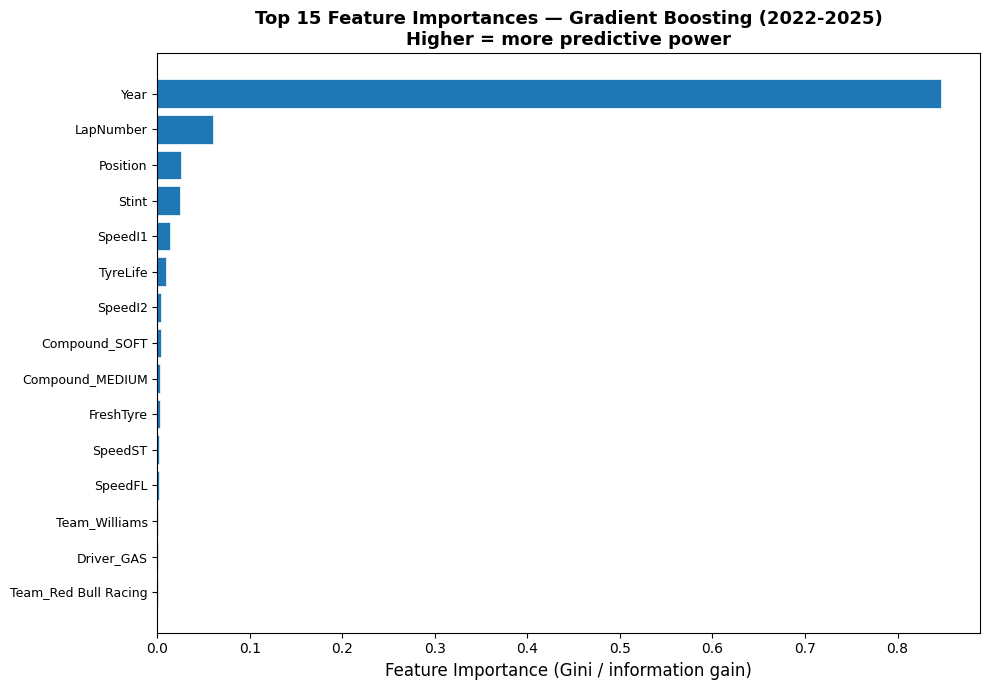

Saved -> multiyear_coefficients.png


In [7]:
# Gradient Boosting: feature importances instead of coefficients
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 15 most important features:')
print(feat_imp.head(15).to_string(index=False))

# Plot top 15
top15 = feat_imp.head(15).sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15['Feature'], top15['Importance'],
        color='#1f77b4', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance (Gini / information gain)', fontsize=12)
ax.set_title(
    'Top 15 Feature Importances — Gradient Boosting (2022-2025)\nHigher = more predictive power',
    fontsize=13, fontweight='bold'
)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('multiyear_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> multiyear_coefficients.png')

---
## 📈 Cell 7 — Actual vs Predicted & Residuals

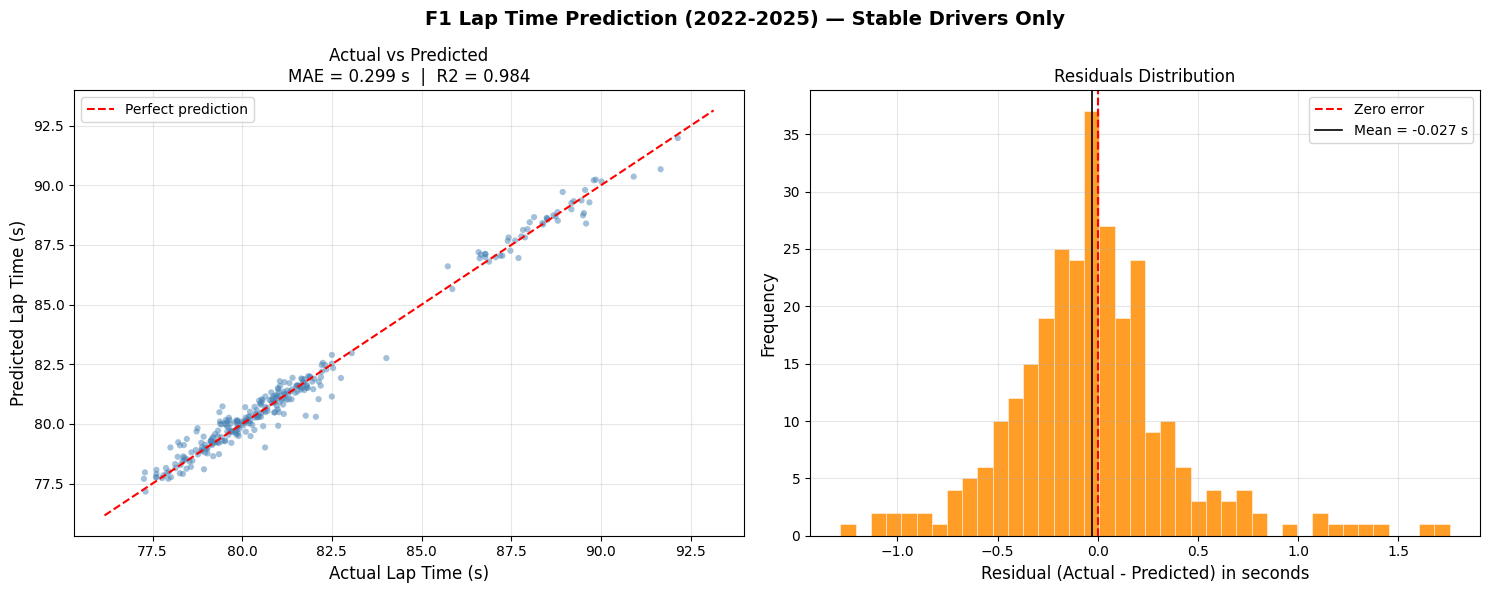

Saved -> multiyear_actual_vs_predicted.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('F1 Lap Time Prediction (2022-2025) — Stable Drivers Only',
             fontsize=14, fontweight='bold')

# Plot 1: Scatter
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue', edgecolors='none')
lo = min(y_test.min(), y_pred.min()) - 1
hi = max(y_test.max(), y_pred.max()) + 1
ax1.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Lap Time (s)', fontsize=12)
ax1.set_ylabel('Predicted Lap Time (s)', fontsize=12)
ax1.set_title(f'Actual vs Predicted\nMAE = {mae:.3f} s  |  R2 = {r2:.3f}', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
residuals = y_test.values - y_pred
ax2.hist(residuals, bins=40, color='darkorange', edgecolor='white', linewidth=0.4, alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax2.axvline(residuals.mean(), color='black', linestyle='-', linewidth=1.2,
            label=f'Mean = {residuals.mean():.3f} s')
ax2.set_xlabel('Residual (Actual - Predicted) in seconds', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residuals Distribution', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiyear_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> multiyear_actual_vs_predicted.png')

---
## 🏆 Cell 8 — Driver Performance Across Years

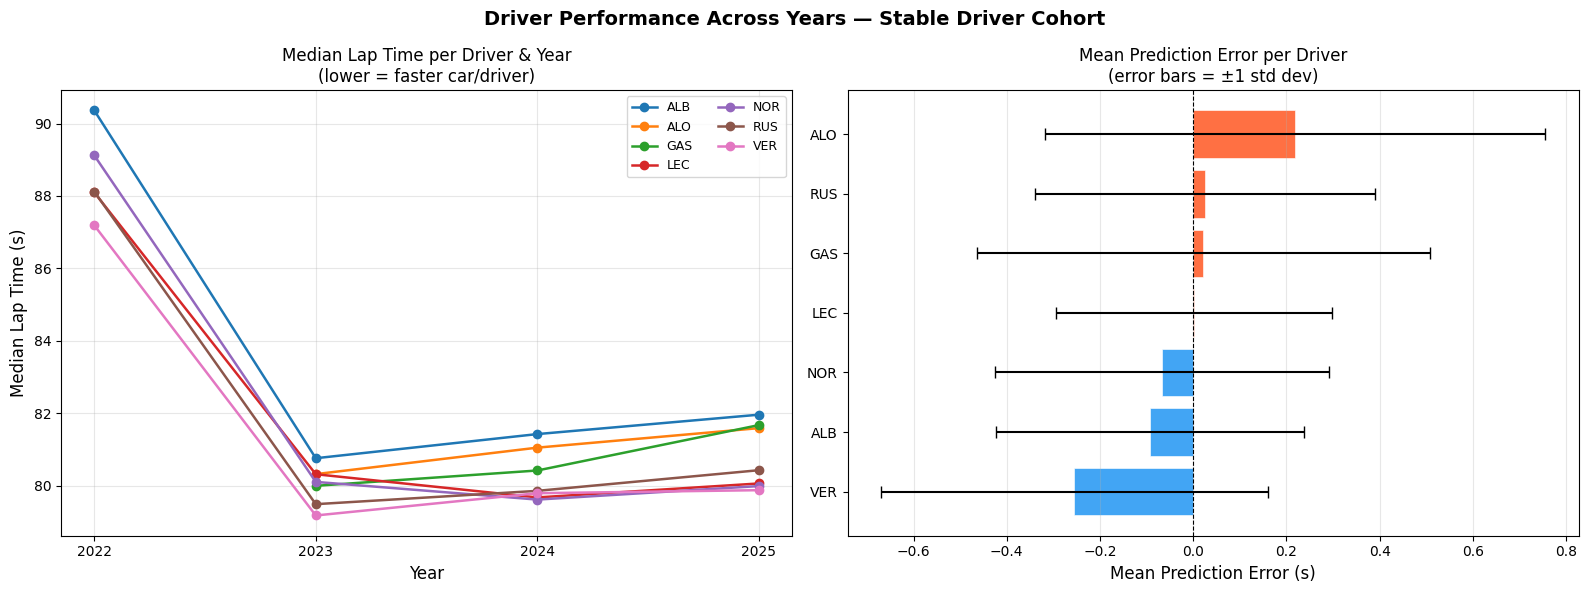

Saved -> multiyear_driver_analysis.png


In [9]:
# Reconstruct test set with metadata
test_indices = X_test.index
laps_test = laps.loc[test_indices].copy()
laps_test['Predicted_sec'] = y_pred
laps_test['Actual_sec']    = y_test.values
laps_test['Error_sec']     = laps_test['Actual_sec'] - laps_test['Predicted_sec']

# ── Plot 1: Average actual lap time per driver per year ───────────────────────
avg_by_year = laps.groupby(['Year', 'Driver'])['LapTime_sec'].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Driver Performance Across Years — Stable Driver Cohort',
             fontsize=14, fontweight='bold')

# Median lap time per driver per year
ax1 = axes[0]
for driver in sorted(avg_by_year['Driver'].unique()):
    d = avg_by_year[avg_by_year['Driver'] == driver]
    ax1.plot(d['Year'], d['LapTime_sec'], 'o-', linewidth=1.8, markersize=6, label=driver)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Median Lap Time (s)', fontsize=12)
ax1.set_title('Median Lap Time per Driver & Year\n(lower = faster car/driver)', fontsize=12)
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Prediction error distribution per driver
ax2 = axes[1]
driver_errors = laps_test.groupby('Driver')['Error_sec'].agg(['mean', 'std']).reset_index()
driver_errors = driver_errors.sort_values('mean')
colors = ['#2196F3' if v < 0 else '#FF5722' for v in driver_errors['mean']]
ax2.barh(driver_errors['Driver'], driver_errors['mean'],
         xerr=driver_errors['std'], color=colors,
         edgecolor='white', linewidth=0.5, capsize=4, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Mean Prediction Error (s)', fontsize=12)
ax2.set_title('Mean Prediction Error per Driver\n(error bars = ±1 std dev)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('multiyear_driver_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> multiyear_driver_analysis.png')

---
## 📝 Cell 9 — Final Summary

In [10]:
print('=' * 60)
print('  F1 MULTI-YEAR LAP TIME PREDICTION MODEL - FINAL SUMMARY')
print('  Spanish Grand Prix 2022 / 2023 / 2024 / 2025')
print('  Stable Driver Cohort Only | Gradient Boosting Regressor')
print('=' * 60)
print()
print(f'  Drivers included     : {sorted(laps["Driver"].unique())}')
print(f'  Total valid laps     : {len(df)}')
print(f'  Training samples     : {len(X_train)}')
print(f'  Testing  samples     : {len(X_test)}')
print(f'  Total features       : {X.shape[1]}')
print()
print('  Performance Metrics:')
print(f'  MAE    = {mae:.4f} s')
print(f'  RMSE   = {rmse:.4f} s')
print(f'  R2     = {r2:.4f}')
print()
print('  Feature Groups:')
print('  Year         -> car development progression across seasons')
print('  LapNumber    -> fuel load proxy')
print('  Stint        -> tyre phase indicator')
print('  TyreLife     -> laps on current tyre (degradation proxy)')
print('  Compound     -> one-hot: Medium / Hard (Soft is reference)')
print('  FreshTyre    -> new vs used tyre')
print('  TrackStatus  -> green / yellow / safety car')
print('  Position     -> race position / dirty air')
print('  Speed traps  -> SpeedI1, SpeedI2, SpeedFL, SpeedST')
print('  Driver       -> one-hot identity encoding')
print('  Team         -> one-hot constructor encoding')
print()
print('  Model: Gradient Boosting Regressor')
print('  - 400 trees, learning_rate=0.05, max_depth=4')
print('  - Huber loss (robust to outlier laps)')
print('  - Captures non-linear tyre degradation & fuel effects')
print('=' * 60)

  F1 MULTI-YEAR LAP TIME PREDICTION MODEL - FINAL SUMMARY
  Spanish Grand Prix 2022 / 2023 / 2024 / 2025
  Stable Driver Cohort Only | Gradient Boosting Regressor

  Drivers included     : ['ALB', 'ALO', 'GAS', 'LEC', 'NOR', 'RUS', 'VER']
  Total valid laps     : 1435
  Training samples     : 1148
  Testing  samples     : 287
  Total features       : 25

  Performance Metrics:
  MAE    = 0.2988 s
  RMSE   = 0.4232 s
  R2     = 0.9838

  Feature Groups:
  Year         -> car development progression across seasons
  LapNumber    -> fuel load proxy
  Stint        -> tyre phase indicator
  TyreLife     -> laps on current tyre (degradation proxy)
  Compound     -> one-hot: Medium / Hard (Soft is reference)
  FreshTyre    -> new vs used tyre
  TrackStatus  -> green / yellow / safety car
  Position     -> race position / dirty air
  Speed traps  -> SpeedI1, SpeedI2, SpeedFL, SpeedST
  Driver       -> one-hot identity encoding
  Team         -> one-hot constructor encoding

  Model: Gradient B